In [2]:
#setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# from pyodide.http import pyfetch
#
# async def download(url, filename):
#     response = await pyfetch(url)
#     if response.status == 200:
#         with open(filename, "wb") as f:
#             f.write(await response.bytes())
# file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"
# await download(file_path, "laptops.csv")

file_name="laptops.csv"
df = pd.read_csv(file_name, header=0)

#本地 Anaconda Jupyter,不用上传文件，直接把数据集的 URL 传给 pd.read_csv("https://...") 就能在线读取
#filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"
#df = pd.read_csv(filepath, header=None)

print(df.info())
df.head()

#调用 NumPy 的 round 函数，将每个值四舍五入保留 2 位小数。
#返回的是一个 DataFrame（而非 Series）。这样写是为了保证赋值时左右两侧类型一致。
#为什么要做这一步？原始数据中 Screen_Size_cm 可能含有类似 33.799999999999997 这样的浮点精度问题。先做修约可以让后续的数据清洗（如用众数填充缺失值、类型转换等）更加准确和干净。
df[['Screen_Size_cm']] = np.round(df[['Screen_Size_cm']],2)
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    str    
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    str    
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), str(2)
memory usage: 24.3 KB
None


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


In [3]:
#Task 1
#找出有缺失的列 Nan为True，有值为False
#目的是摸清数据集中每一列的缺失值情况。
missing_data = df.isnull()
for column in missing_data.columns.values.tolist():
    print(column)
    print(missing_data[column].value_counts())


Unnamed: 0
Unnamed: 0
False    238
Name: count, dtype: int64
Manufacturer
Manufacturer
False    238
Name: count, dtype: int64
Category
Category
False    238
Name: count, dtype: int64
Screen
Screen
False    238
Name: count, dtype: int64
GPU
GPU
False    238
Name: count, dtype: int64
OS
OS
False    238
Name: count, dtype: int64
CPU_core
CPU_core
False    238
Name: count, dtype: int64
Screen_Size_cm
Screen_Size_cm
False    234
True       4
Name: count, dtype: int64
CPU_frequency
CPU_frequency
False    238
Name: count, dtype: int64
RAM_GB
RAM_GB
False    238
Name: count, dtype: int64
Storage_GB_SSD
Storage_GB_SSD
False    238
Name: count, dtype: int64
Weight_kg
Weight_kg
False    233
True       5
Name: count, dtype: int64
Price
Price
False    238
Name: count, dtype: int64


In [6]:
#Task2
# Weight_kg 用均值填充
avg_weight = df['Weight_kg'].astype('float').mean(axis=0)
df['Weight_kg'] = df['Weight_kg'].replace(np.nan, avg_weight)

# Screen_Size_cm 用众数填充
#idxmax() 本身的作用是：返回索引中最大值对应的那个标签。
#.value_counts().idxmax();这两者组合起来后，才可以取众数
# idxmax() → 返回"谁最多"（取值本身）
# max() → 返回"最多有几个"（取计数）
common_screen_size = df['Screen_Size_cm'].value_counts().idxmax()
df['Screen_Size_cm'] = df['Screen_Size_cm'].replace(np.nan, common_screen_size)

In [10]:
#Task3
#修正数据类型
#若数据里还有 ? 字符串，astype 会抛 ValueError: could not convert string to float: '?'——所以必须先完成缺失填充。但这里是高质量数据
df[['Weight_kg','Screen_Size_cm']] = df[['Weight_kg','Screen_Size_cm']].astype('float')

In [14]:
#Task4
#单位换算（对应公式） + 改名
df['Weight_kg'] = df['Weight_kg'] * 2.205
df.rename(columns={'Weight_kg':'Weight_pounds'}, inplace=True)
df['Screen_Size_cm'] = df['Screen_Size_cm'] / 2.54
df.rename(columns={'Screen_Size_cm':'Screen_Size_inch'}, inplace=True)

#归一化（公式）
df['CPU_frequency'] = df['CPU_frequency'] / df['CPU_frequency'].max()

Text(0.5, 1.0, 'Price bins')

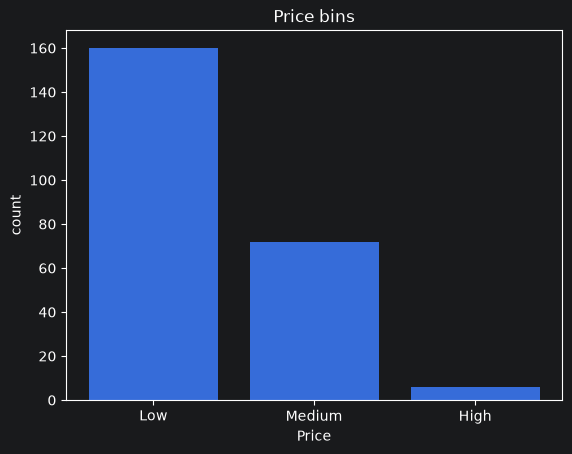

In [16]:
#Task5  Price 分 3 箱 + 柱状图
bins = np.linspace(min(df['Price']), max(df['Price']), 4)
group_names = ['Low', 'Medium', 'High']
#包含最小值（include_lowest=True）。默认左边界是开区间 (`，加了此参数后第一个区间变成闭区间[，确保最小值不被漏掉 |]
df['Price-binned'] = pd.cut(df['Price'], bins, labels=group_names, include_lowest=True)
plt.bar(group_names, df['Price-binned'].value_counts())
plt.xlabel('Price')
plt.ylabel('count')
plt.title('Price bins')

In [17]:
#Task 6  Screen 转指示变量并删除原列
dummy_variable_1 = pd.get_dummies(df['Screen'])
dummy_variable_1.rename(columns={'IPS Panel':'Screen-IPS_panel','Full HD':'Screen-Full_HD'}, inplace=True)
df = pd.concat([df, dummy_variable_1], axis=1)
df.drop('Screen', axis=1, inplace=True)
print(df.head())

   Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  Screen_Size_inch  \
0           0         Acer         4    2   1         5         14.000000   
1           1         Dell         3    1   1         3         15.598425   
2           2         Dell         3    1   1         7         15.598425   
3           3         Dell         4    2   1         5         13.299213   
4           4           HP         4    2   1         7         15.598425   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_pounds  Price Price-binned  \
0            1.6       8             256        3.52800    978          Low   
1            2.0       4             256        4.85100    634          Low   
2            2.7       8             256        4.85100    946          Low   
3            1.6       8             128        2.69010   1244          Low   
4            1.8       8             256        4.21155    837          Low   

   Screen-Full_HD  Screen-IPS_panel  
0           False       